
<h1 align="center"><B> <FONT COLOR="#2E7D32">India Air Quality & Crop Yield Analysis - Machine Learning - Lab 1</FONT></B></h1>

<B><h3 align="center">Data Preprocessing, Visualisation & Exploratory Data Analysis</h3>

<h3 align="center">Environment Awareness Month Special Investigation</B></h3>


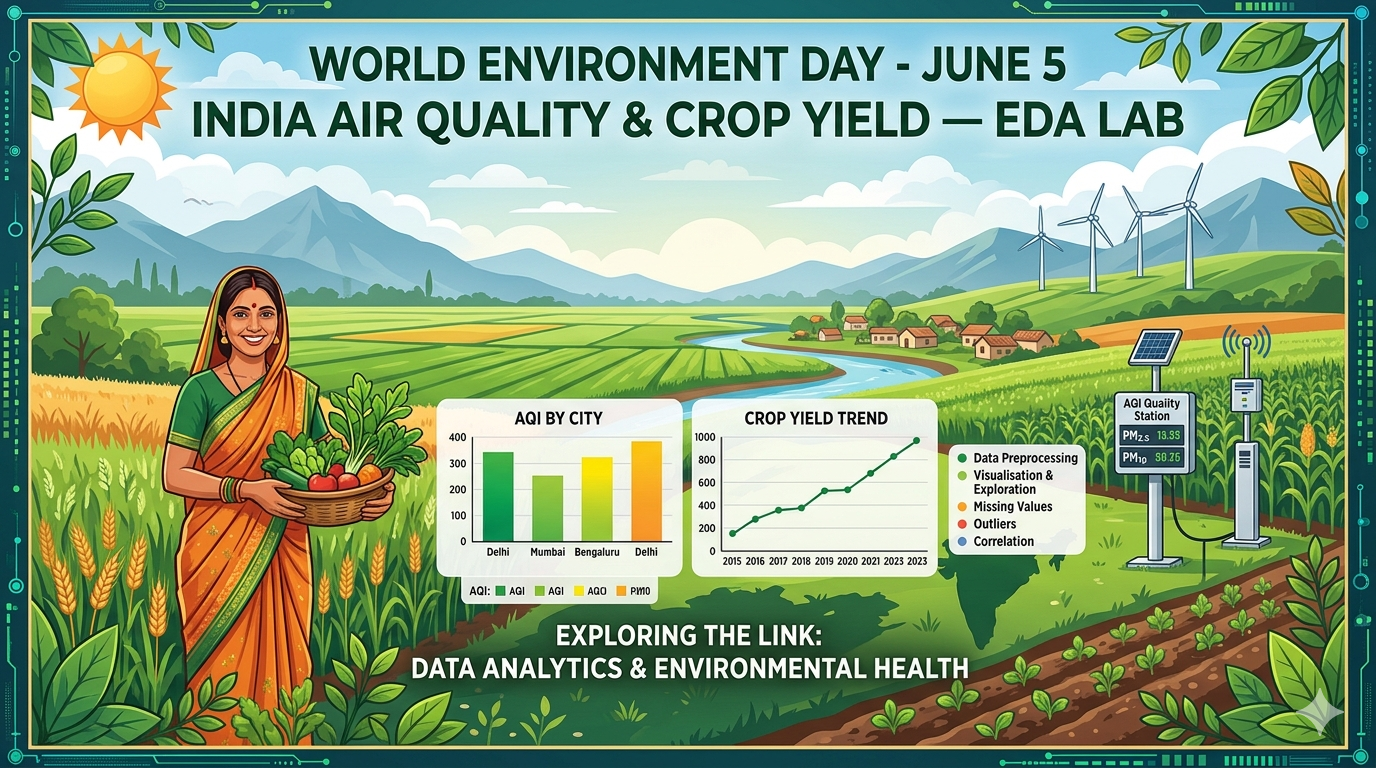

In [ ]:
# @title
from IPython.display import Image, display

display(Image('/content/ML_Lab1.png', width=800))


<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 1 - Data Profiling - Understanding the Structure and Quality of the Datasets</FONT></B></h2>

<h3><b>
Loading the datasets
</b></h3>

In [ ]:
import pandas as pd

City_DataFrame = pd.read_csv("city_day.csv")
Crop_DataFrame = pd.read_csv("crop_production.csv")

<h3><b>
First 5 Rows
</b></h3>

In [ ]:
City_DataFrame.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
Crop_DataFrame.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


<h3><b>
Dimensions
</b></h3>

In [ ]:
print("City Dataset Shape:", City_DataFrame.shape)
print("Crop Dataset Shape:", Crop_DataFrame.shape)

City Dataset Shape: (29531, 16)
Crop Dataset Shape: (246091, 7)


<h3><b>
Information About Columns
</b></h3>

In [ ]:
City_DataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
Crop_DataFrame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


<h3><b>
Statistical Summary
</b></h3>

In [ ]:
City_DataFrame.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [ ]:
Crop_DataFrame.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


<h3><b>
Missing Values
</b></h3>

In [ ]:
City_DataFrame.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


<h3><b>
Missing Values in Air Quality Dataset (Bar Chart)
</b></h3>

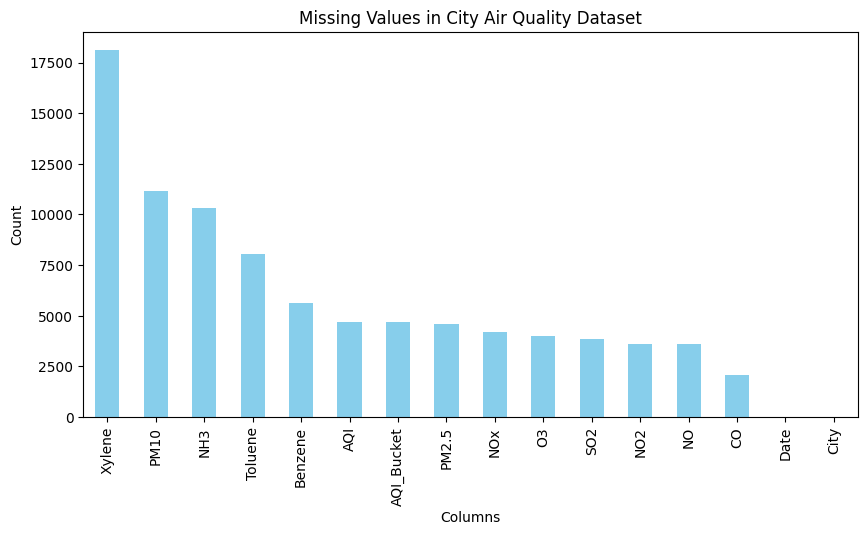

In [ ]:
import matplotlib.pyplot as plt

City_DataFrame.isnull().sum().sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5),
    color='skyblue'
)

plt.title("Missing Values in City Air Quality Dataset")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

In [ ]:
Crop_DataFrame.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


<h3><b>
Missing Values in Crop Dataset (Bar Chart)
</b></h3>

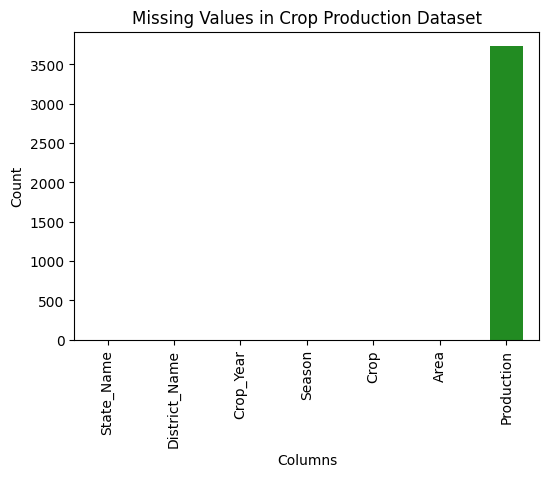

In [ ]:
Crop_DataFrame.isnull().sum().plot(
    kind='bar',
    figsize=(6,4),
    color='forestgreen'
)

plt.title("Missing Values in Crop Production Dataset")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

<h3><b>
Duplicate Records
</b></h3>

In [ ]:
print("Duplicate rows in City Dataset:",
      City_DataFrame.duplicated().sum())

print("Duplicate rows in Crop Dataset:",
      Crop_DataFrame.duplicated().sum())

Duplicate rows in City Dataset: 0
Duplicate rows in Crop Dataset: 0


<h3><b>
Unique Values
</b></h3>

In [ ]:
City_DataFrame.nunique()

,0
City,26
Date,2009
PM2.5,11716
PM10,12571
NO,5776
NO2,7404
NOx,8156
NH3,5922
CO,1779
SO2,4761


In [ ]:
Crop_DataFrame.nunique()

,0
State_Name,33
District_Name,646
Crop_Year,19
Season,6
Crop,124
Area,38442
Production,51627


<h3><b>
Inspecting Categorical Columns and Unique Values
</b></h3>

<h4><b>
Crop
</b></h4>

In [ ]:
object_cols_crop = Crop_DataFrame.select_dtypes(include='object').columns

for col in object_cols_crop:
    print(f"\n{col}")
    print("Unique values:", Crop_DataFrame[col].nunique())

    # Show values with spaces made visible
    sample_values = Crop_DataFrame[col].dropna().unique()[:20]

    for value in sample_values:
        print(repr(value))


State_Name
Unique values: 33
'Andaman and Nicobar Islands'
'Andhra Pradesh'
'Arunachal Pradesh'
'Assam'
'Bihar'
'Chandigarh'
'Chhattisgarh'
'Dadra and Nagar Haveli'
'Goa'
'Gujarat'
'Haryana'
'Himachal Pradesh'
'Jammu and Kashmir '
'Jharkhand'
'Karnataka'
'Kerala'
'Madhya Pradesh'
'Maharashtra'
'Manipur'
'Meghalaya'

District_Name
Unique values: 646
'NICOBARS'
'NORTH AND MIDDLE ANDAMAN'
'SOUTH ANDAMANS'
'ANANTAPUR'
'CHITTOOR'
'EAST GODAVARI'
'GUNTUR'
'KADAPA'
'KRISHNA'
'KURNOOL'
'PRAKASAM'
'SPSR NELLORE'
'SRIKAKULAM'
'VISAKHAPATANAM'
'VIZIANAGARAM'
'WEST GODAVARI'
'ANJAW'
'CHANGLANG'
'DIBANG VALLEY'
'EAST KAMENG'

Season
Unique values: 6
'Kharif     '
'Whole Year '
'Autumn     '
'Rabi       '
'Summer     '
'Winter     '

Crop
Unique values: 124
'Arecanut'
'Other Kharif pulses'
'Rice'
'Banana'
'Cashewnut'
'Coconut '
'Dry ginger'
'Sugarcane'
'Sweet potato'
'Tapioca'
'Black pepper'
'Dry chillies'
'other oilseeds'
'Turmeric'
'Maize'
'Moong(Green Gram)'
'Urad'
'Arhar/Tur'
'Groundnut'
'Sunfl

<h3><b>
City (Air Quality)
</b></h3>

In [ ]:
object_cols_city = City_DataFrame.select_dtypes(include='object').columns

for col in object_cols_city:
    print(f"\n===== {col} =====")
    print("Unique values:", City_DataFrame[col].nunique())

    sample_values = City_DataFrame[col].dropna().unique()[:20]

    for value in sample_values:
        print(repr(value))


===== City =====
Unique values: 26
'Ahmedabad'
'Aizawl'
'Amaravati'
'Amritsar'
'Bengaluru'
'Bhopal'
'Brajrajnagar'
'Chandigarh'
'Chennai'
'Coimbatore'
'Delhi'
'Ernakulam'
'Gurugram'
'Guwahati'
'Hyderabad'
'Jaipur'
'Jorapokhar'
'Kochi'
'Kolkata'
'Lucknow'

===== Date =====
Unique values: 2009
'2015-01-01'
'2015-01-02'
'2015-01-03'
'2015-01-04'
'2015-01-05'
'2015-01-06'
'2015-01-07'
'2015-01-08'
'2015-01-09'
'2015-01-10'
'2015-01-11'
'2015-01-12'
'2015-01-13'
'2015-01-14'
'2015-01-15'
'2015-01-16'
'2015-01-17'
'2015-01-18'
'2015-01-19'
'2015-01-20'

===== AQI_Bucket =====
Unique values: 6
'Poor'
'Very Poor'
'Severe'
'Moderate'
'Satisfactory'
'Good'


<h3><b>
Inspecting Numerical Values in Crop Dataset
</b></h3>

In [ ]:
numeric_cols_crop = Crop_DataFrame.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols_crop:
    print(f"\n{col}")

    print("Minimum :", Crop_DataFrame[col].min())
    print("Maximum :", Crop_DataFrame[col].max())
    print("Mean    :", Crop_DataFrame[col].mean())
    print("Median  :", Crop_DataFrame[col].median())
    print("Skewness:", Crop_DataFrame[col].skew())


Crop_Year
Minimum : 1997
Maximum : 2015
Mean    : 2005.6430182330926
Median  : 2006.0
Skewness: 0.009580701659528757

Area
Minimum : 0.04
Maximum : 8580100.0
Mean    : 12002.82086370489
Median  : 582.0
Skewness: 48.00127769770893

Production
Minimum : 0.0
Maximum : 1250800000.0
Mean    : 582503.4422509808
Median  : 729.0
Skewness: 40.74153975191237


<h3><b>
Skewness of Numerical Variables - Crop Dataset (Horizontal Bar Chart)
</b></h3>

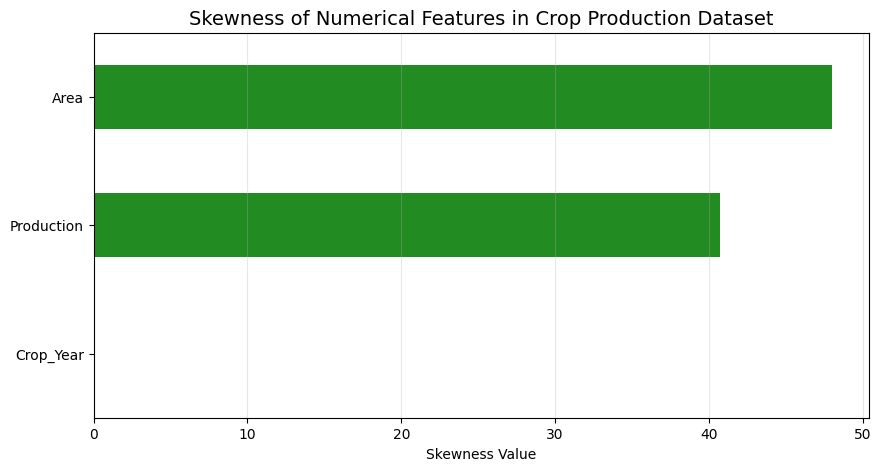

In [ ]:
crop_skew = Crop_DataFrame.select_dtypes(
    include=['float64','int64']
).skew()

plt.figure(figsize=(10,5))

crop_skew.sort_values().plot(
    kind='barh',
    color='forestgreen'
)

plt.title(
    "Skewness of Numerical Features in Crop Production Dataset",
    fontsize=14
)

plt.xlabel("Skewness Value")
plt.grid(axis='x', alpha=0.3)

plt.show()

The crop production dataset exhibits strong positive skewness, particularly in the Area and Production variables, indicating the presence of highly uneven distributions and extreme values.

<h3><b>
Inspecting Numerical Values in City Dataset (Air Quality)
</b></h3>

In [ ]:
numeric_cols_city = City_DataFrame.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols_city:
    print(f"\n{col}")

    print("Minimum :", City_DataFrame[col].min())
    print("Maximum :", City_DataFrame[col].max())
    print("Mean    :", City_DataFrame[col].mean())
    print("Median  :", City_DataFrame[col].median())
    print("Skewness:", City_DataFrame[col].skew())


PM2.5
Minimum : 0.04
Maximum : 949.99
Mean    : 67.45057794890306
Median  : 48.57
Skewness: 3.3699598508656305

PM10
Minimum : 0.01
Maximum : 1000.0
Mean    : 118.12710293078135
Median  : 95.68
Skewness: 2.0531890996443773

NO
Minimum : 0.02
Maximum : 390.68
Mean    : 17.574729662029362
Median  : 9.89
Skewness: 3.8831662754061522

NO2
Minimum : 0.01
Maximum : 362.21
Mean    : 28.560659061126955
Median  : 21.69
Skewness: 2.46455958981977

NOx
Minimum : 0.0
Maximum : 467.63
Mean    : 32.30912333307031
Median  : 23.52
Skewness: 2.5699146172425547

NH3
Minimum : 0.01
Maximum : 352.89
Mean    : 23.48347601937197
Median  : 15.85
Skewness: 4.083993435995748

CO
Minimum : 0.0
Maximum : 175.81
Mean    : 2.2485982090856145
Median  : 0.89
Skewness: 8.87832152174809

SO2
Minimum : 0.01
Maximum : 193.86
Mean    : 14.53197725590996
Median  : 9.16
Skewness: 4.083659554753711

O3
Minimum : 0.01
Maximum : 257.73
Mean    : 34.49143047551845
Median  : 30.84
Skewness: 1.330119322144908

Benzene
Minimum :

<h3><b>
Skewness of Numerical Variables - Air Quality Dataset (Horizontal Bar Chart)
</b></h3>

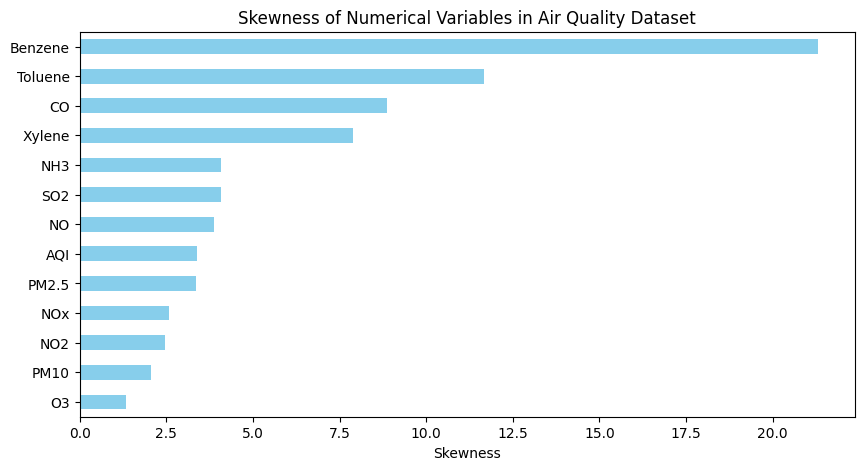

In [ ]:
city_skew = City_DataFrame.select_dtypes(include=['float64','int64']).skew()

plt.figure(figsize=(10,5))
city_skew.sort_values().plot(
    kind='barh',
    color='skyblue'
)

plt.title(
    "Skewness of Numerical Variables in Air Quality Dataset"
)

plt.xlabel("Skewness")
plt.show()

Most air quality variables are positively skewed, with pollutants such as Benzene, Toluene, and CO showing the highest skewness, suggesting the presence of extreme observations and non-normal distributions.

<h3><b>
Largest Production Values
</b></h3>

In [ ]:
Crop_DataFrame.nlargest(
    10,
    'Production'
)[['State_Name','Crop','Production']]

,State_Name,Crop,Production
178273,Tamil Nadu,Coconut,1.250800e+09
178331,Tamil Nadu,Coconut,1.212000e+09
100654,Kerala,Coconut,1.125000e+09
100612,Kerala,Coconut,1.063000e+09
100149,Kerala,Coconut,1.059000e+09
100391,Kerala,Coconut,1.001000e+09
100135,Kerala,Coconut,9.990000e+08
100598,Kerala,Coconut,9.520000e+08
100373,Kerala,Coconut,9.480000e+08
100639,Kerala,Coconut,9.467810e+08


Inspecting the highest production records helps determine whether unusually large values correspond to specific crops or regions. This provides context for understanding why the Production column exhibits strong positive skewness.

<h3><b>
Highest AQI Readings
</b></h3>

In [ ]:
City_DataFrame.nlargest(
    10,
    'AQI'
)[['City','Date','AQI']]

,City,Date,AQI
1145,Ahmedabad,2018-02-19,2049.0
1136,Ahmedabad,2018-02-10,1917.0
560,Ahmedabad,2016-07-14,1842.0
1048,Ahmedabad,2017-11-14,1747.0
1463,Ahmedabad,2019-01-03,1719.0
1417,Ahmedabad,2018-11-18,1672.0
1420,Ahmedabad,2018-11-21,1646.0
1407,Ahmedabad,2018-11-08,1630.0
1127,Ahmedabad,2018-02-01,1613.0
1746,Ahmedabad,2019-10-13,1595.0


Examining the highest AQI values helps identify unusually large pollution measurements and provides an early indication of potential extreme observations that may influence descriptive statistics

<h3><b>
Examining Temporal Coverage and Common Years
</b></h3>

In [ ]:
City_DataFrame['Date']=pd.to_datetime(
    City_DataFrame['Date']
)

air_years=set(
    City_DataFrame['Date'].dt.year.unique()
)

crop_years=set(
    Crop_DataFrame['Crop_Year'].unique()
)

print(sorted(
    air_years.intersection(crop_years)
))

[np.int32(2015)]


Two datasets will be combined later,so it is important to examine their temporal overlap. Identifying common years allows us to assess whether direct year wise comparisons are possible and highlights any limitations in integrating the datasets.

<h3><b>
Dataset Profile : city_day.csv
</b></h3>
<ul>
<li><b>Rows:</b> 29,531</li>
<li><b>Columns:</b> 16</li>
<li><b>Data Types:</b> Numerical and Categorical</li>
<li><b>Major Features:</b> City, Date, PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene, Xylene, AQI and AQI_Bucket</li>
<li><b>Unique Cities:</b> 26</li>
<li><b>AQI Categories:</b> 6</li>
<li><b>Duplicate Records:</b> 0</li>
<li><b>Missing Values:</b> Present in several pollutant variables</li>

<li><b>Highest Missing Values:</b> Xylene, PM10 and NH3</li>
<li><b>Time Coverage: </b>2015–2020</li>
</ul>

<h3><b>Observation</b></h3>

The air quality dataset contains measurements from 26 cities and exhibits missing values across multiple pollutant variables. Among them, Xylene, PM10, and NH3 have the largest number of missing observations. Skewness analysis shows that most pollutant variables are positively skewed, with Benzene, Toluene, and CO displaying particularly high skewness, indicating the presence of extreme observations. The highest recorded AQI values are concentrated in Ahmedabad.

<h3><b>
Dataset Profile : crop_production.csv
</b></h3>
<ul>
<li><b>Rows:</b> 246,091</li>
<li><b>Columns:</b> 7</li>
<li><b>Data Types:</b> Numerical and Categorical</li>
<li><b>Major Features:</b> State_Name, District_Name, Crop_Year, Season, Crop, Area and Production</li>
<li><b>Unique States:</b> 33</li>
<li><b>Unique Districts:</b> 646</li>
<li><b>Unique Crops:</b> 124</li>
<li><b>Duplicate Records:</b> 0</li>
<li><b>Missing Values:</b> Present only in the Production column (3,730 values)</li>
<li><b>Time Coverage: </b>1997–2015</li>
</ul>

<h3><b>Observation</b></h3>

The crop production dataset is large and contains no duplicate records. Missing values are limited to the Production column, where 3,730 entries are absent. Statistical analysis and skewness plots indicate that the Area and Production variables are highly positively skewed, suggesting the presence of extreme values and uneven distributions. Examination of the largest production records shows that crops such as Coconut contribute to exceptionally high production values.

# Observations & Concerns

## Crop Production Dataset

* The **Production** column contains **3,730 missing values**, whereas all other columns are complete.
* No duplicate records were found.
* **Area** and **Production** exhibit strong positive skewness, indicating highly uneven distributions.
* The maximum production value reaches approximately **1.25 billion**, creating a substantial gap between average and extreme values.
* The largest production records are dominated by **Coconut** cultivation, particularly in **Tamil Nadu** and **Kerala**, which heavily influence summary statistics.

## Air Quality Dataset

* Missing values are present in several variables, with **Xylene**, **PM10**, and **NH3** having the greatest number of missing observations.
* No duplicate records were detected.
* Most numerical variables show positive skewness.
* **Benzene**, **Toluene**, and **CO** possess the highest skewness values, suggesting the presence of outliers and non-normal distributions.
* The highest AQI readings are observed in **Ahmedabad**, with recorded values exceeding 1500.
* The dataset contains measurements from **26 cities** and six AQI categories.

## Temporal Overlap Between Datasets

* Crop production data spans **1997–2015**.
* Air quality data spans **2015–2020**.
* The only common year between the datasets is **2015**.

> **Primary Concern:** Since the two datasets overlap only in the year **2015**, direct year-wise integration would yield limited matching records. Therefore, any combined analysis should account for this limited temporal overlap and may require aggregation rather than strict year-by-year matching.


<h3><b>
Summary of Functions Used for Task 1<ol>
<li>shape()-Determines the number of rows and columns.
<li>info()-Provides column names, data types and non-null counts.
<li>describe()-Generates summary statistics for numerical variables.
<li>describe(include='object')-Summarizes categorical variables.
<li>isnull().sum()-Identifies missing values.
<li>duplicated().sum()-Counts duplicate records.
<li>nunique()-Determines the number of unique values in each column.</li>
<ol></b></h3>


<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 2 - Missing Value Treatment - Handling Missing Values Using Various Strategies</FONT></B></h2>

<h3><b>
Missing Values
</b></h3>

In [ ]:
City_DataFrame.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [ ]:
Crop_DataFrame.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


<h3><b>
Crop Dataset
</b></h3>

In [ ]:
# Remove whitespace from categorical columns
Crop_DataFrame['State_Name'] = Crop_DataFrame['State_Name'].str.strip()
Crop_DataFrame['Season'] = Crop_DataFrame['Season'].str.strip()
Crop_DataFrame['Crop'] = Crop_DataFrame['Crop'].str.strip()

# Production (1.5% missing)
Crop_DataFrame['Production'] = (
    Crop_DataFrame
    .groupby(['State_Name', 'Crop', 'Season'])['Production']
    .transform(lambda x: x.fillna(x.median()))
)

# Global median fallback
Crop_DataFrame['Production'] = (
    Crop_DataFrame['Production']
    .fillna(Crop_DataFrame['Production'].median())
)

<h3><b>
City Dataset
</b></h3>

In [ ]:
# Datetime parsing
City_DataFrame['Date'] = pd.to_datetime(City_DataFrame['Date'])

City_DataFrame['Year'] = City_DataFrame['Date'].dt.year
City_DataFrame['Month'] = City_DataFrame['Date'].dt.month

# Core pollutants
core_cols = [
    'PM2.5',
    'PM10',
    'NO',
    'NO2',
    'NOx',
    'SO2',
    'O3',
    'CO',
    'NH3',
    'Benzene',
    'Toluene'
]

for col in core_cols:

    City_DataFrame[col] = (
        City_DataFrame
        .groupby('City')[col]
        .transform(lambda x: x.fillna(x.median()))
    )

    # Global median fallback
    City_DataFrame[col] = (
        City_DataFrame[col]
        .fillna(City_DataFrame[col].median())
    )


# AQI interpolation
City_DataFrame = City_DataFrame.sort_values(['City', 'Date'])

City_DataFrame['AQI'] = (
    City_DataFrame
    .groupby('City')['AQI']
    .transform(
        lambda x: x.interpolate(
            method='linear',
            limit_direction='both'
        )
    )
)

# Global median fallback
City_DataFrame['AQI'] = (
    City_DataFrame['AQI']
    .fillna(City_DataFrame['AQI'].median())
)

# Drop Xylene
City_DataFrame.drop(columns=['Xylene'], inplace=True)


# Recreate AQI_Bucket
def aqi_bucket(v):

    if pd.isna(v):
        return 'Unknown'
    elif v <= 50:
        return 'Good'
    elif v <= 100:
        return 'Satisfactory'
    elif v <= 200:
        return 'Moderate'
    elif v <= 300:
        return 'Poor'
    elif v <= 400:
        return 'Very Poor'
    else:
        return 'Severe'


City_DataFrame['AQI_Bucket'] = (
    City_DataFrame['AQI']
    .apply(aqi_bucket)
)




<h4><b>
Verifying Null Count
</b></h4>

In [ ]:
City_DataFrame.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [ ]:
Crop_DataFrame.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,0


<h3><b>
Conclusion
</b></h3>
<h2>Justification Summary</h2>

<table>
    <tr>
        <th>Column</th>
        <th>Strategy</th>
        <th>Rationale</th>
    </tr>
    <tr>
        <td><b>Production (crop)</b></td>
        <td>Median imputation grouped by <b>State × Crop × Season</b></td>
        <td>Preserves regional and seasonal context; median is robust to extreme coconut and sugarcane values.</td>
    </tr>
    <tr>
        <td><b>Season, State_Name</b></td>
        <td>Strip whitespace</td>
        <td>Not missing values—only encoding noise that affects grouping operations.</td>
    </tr>
    <tr>
        <td><b>PM2.5 – Toluene</b></td>
        <td>Median imputation per <b>City</b></td>
        <td>Pollution variables are right-skewed; city-level grouping preserves geographical differences.</td>
    </tr>
    <tr>
        <td><b>AQI</b></td>
        <td>Linear interpolation within <b>City × Time</b></td>
        <td>AQI is a continuous time series; adjacent readings are the best predictors of missing values.</td>
    </tr>
    <tr>
        <td><b>Xylene</b></td>
        <td>Drop column</td>
        <td>61.3% missing values; imputation would fabricate more than half the column.</td>
    </tr>
    <tr>
        <td><b>AQI_Bucket</b></td>
        <td>Re-derive from cleaned AQI</td>
        <td>Ensures consistency with AQI values and fills residual missing categories.</td>
    </tr>
</table>

<p>
<b>Why not Mean Imputation?</b><br>
Mean imputation is sensitive to extreme values and outliers commonly present in crop production and pollution datasets. Median imputation provides a more robust estimate for right-skewed environmental variables and helps preserve the underlying distribution.
</p>



<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 3: State Name Standardization and Duplicate Removal - Preparing Both Datasets for Reliable Merging</FONT></B></h2>
</b></h3>

<h5><b>Problem - City Dataset does not have a state column.</b></h5>

<h3><b>Unique Cities
</b></h3>

In [ ]:
City_DataFrame['City'].sort_values().unique()

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

<h3><b>
City_State Mapping using Dictionary Approach
</b></h3>

In [ ]:
city_state_map = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

<h3><b>
Creating State_Name in City Dataset
</b></h3>

In [ ]:
City_DataFrame['State'] = (
    City_DataFrame['City']
    .map(city_state_map)
)

<h3><b>
Trailing Spaces in State Names
</b></h3>

In [ ]:
trailing_issues = [
    state
    for state in Crop_DataFrame['State_Name'].unique()
    if state != state.strip()
]

print("Trailing-space state names remaining:")
print(trailing_issues)

Trailing-space state names remaining:
[]


<h3><b>
Missing State Names
</b></h3>

In [ ]:
City_DataFrame['State_Name'].isnull().sum()

np.int64(0)

<h3><b>
Counts Before Duplicate Removal
</b></h3>

In [ ]:
print("City Dataset Records Before:", len(City_DataFrame))
print("Crop Dataset Records Before:", len(Crop_DataFrame))

City Dataset Records Before: 29531
Crop Dataset Records Before: 246091


<h3><b>
Remove Duplicate Records
</b></h3>

In [ ]:
Crop_DataFrame.drop_duplicates(inplace=True)
City_DataFrame.drop_duplicates(inplace=True)


<h3><b>
Counts After Duplicate Removal
</b></h3>

In [ ]:
print("City Dataset Records After:", len(City_DataFrame))
print("Crop Dataset Records After:", len(Crop_DataFrame))

City Dataset Records After: 29531
Crop Dataset Records After: 246091


<h3><b>
Verify Duplicates Were Removed
</b></h3>

In [ ]:
city_duplicates = City_DataFrame.duplicated().sum()
crop_duplicates = Crop_DataFrame.duplicated().sum()

print("Duplicates in City Dataset:", city_duplicates)
print("Duplicates in Crop Dataset:", crop_duplicates)

Duplicates in City Dataset: 0
Duplicates in Crop Dataset: 0


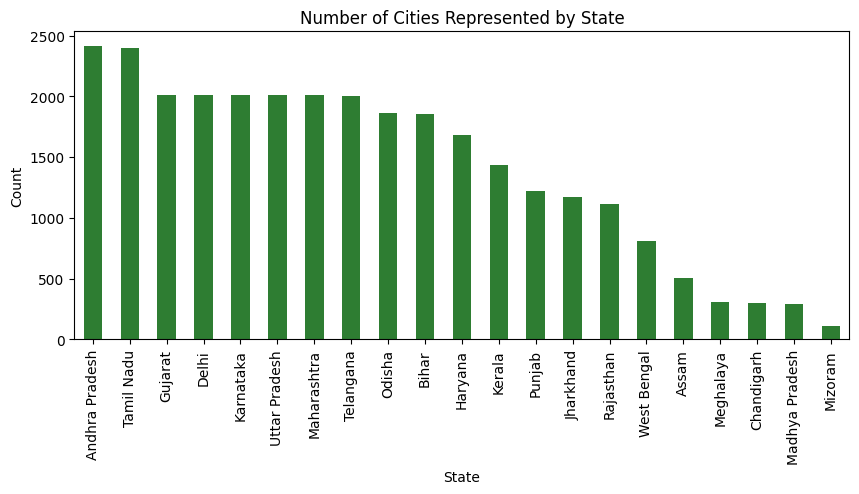

In [ ]:
City_DataFrame['State_Name'].value_counts().plot(
    kind='bar',
    color='#2E7D32',
    figsize=(10,4)
)

plt.title("Number of Cities Represented by State")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

<h2>
Inconsistencies Identified and Corrections Applied
</h2>

<table>
<tr>
<th>Issue</th>
<th>Correction</th>
</tr>

<tr>
<td>The city dataset did not contain a State_Name column.</td>
<td>A State_Name column was created using a city-to-state mapping dictionary based on the unique city names present in the dataset.</td>
</tr>

<tr>
<td>State names could contain leading or trailing spaces.</td>
<td>Whitespace was removed using the <code>str.strip()</code> function.</td>
</tr>

<tr>
<td>Multiple spaces between words could lead to inconsistencies.</td>
<td>State names were standardized using regular expressions to replace consecutive spaces with a single space.</td>
</tr>

<tr>
<td>Duplicate records could result in redundant information and affect future analysis.</td>
<td>Duplicate rows were identified and removed using the <code>drop_duplicates()</code> function.</td>
</tr>

</table>

<br>

<h3> <b>
Observation
</b></h3>

- A State_Name column was created in the air quality dataset by mapping cities to their corresponding states.
- No trailing spaces remained in the crop dataset after cleaning.
- No duplicate rows were detected in either dataset.
- Record counts remained unchanged after duplicate removal.
- Several states are common to both datasets and can be used for integration.
- Some states exist only in one dataset, limiting complete nationwide merging.
- The number of cities represented varies considerably across states, with Andhra Pradesh and Tamil Nadu having the highest representation.
<h3><b>
Conclusion
</b></h3>

The unique city names were first identified and used to construct a city-to-state mapping dictionary, enabling the creation of a common State_Name column. State names were then standardized and duplicate records were removed. As a result, both datasets now share a consistent key and are ready to be merged reliably for further analysis.


<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 4: AQI Distribution Analysis - Investigating the Distribution of Air Quality Index(AQI)</FONT></B></h2>
</b></h3>

<h3><b>Plot: Histogram with KDE</b></h3>

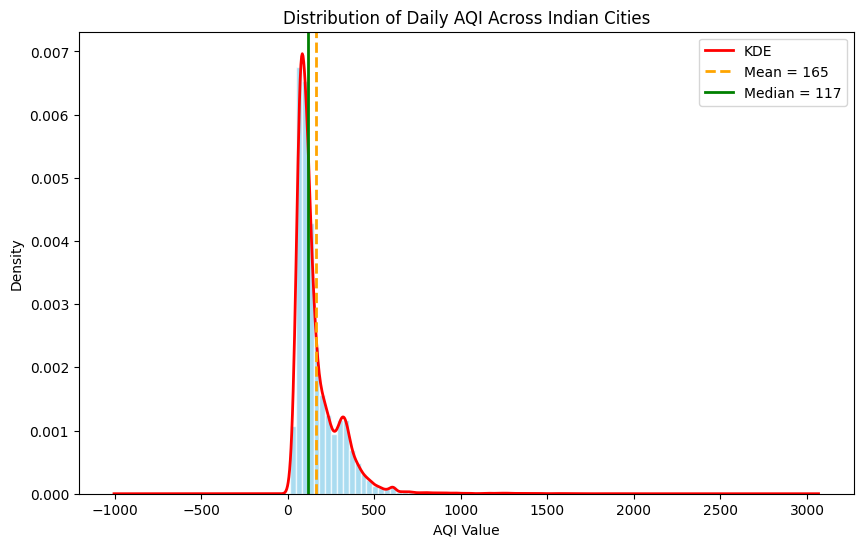

In [ ]:
plt.figure(figsize=(10,6))

aqi_clean = City_DataFrame['AQI'].dropna()

plt.hist(
    aqi_clean,
    bins=60,
    density=True,
    color='skyblue',
    alpha=0.7,
    edgecolor='white'
)

aqi_clean.plot.kde(
    color='red',
    linewidth=2,
    label='KDE'
)

plt.axvline(
    aqi_clean.mean(),
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {aqi_clean.mean():.0f}'
)

plt.axvline(
    aqi_clean.median(),
    color='green',
    linewidth=2,
    label=f'Median = {aqi_clean.median():.0f}'
)

plt.xlabel('AQI Value')
plt.ylabel('Density')
plt.title('Distribution of Daily AQI Across Indian Cities')
plt.legend()

plt.show()

<h3><b>Plot 2: Box Plot</b></h3>

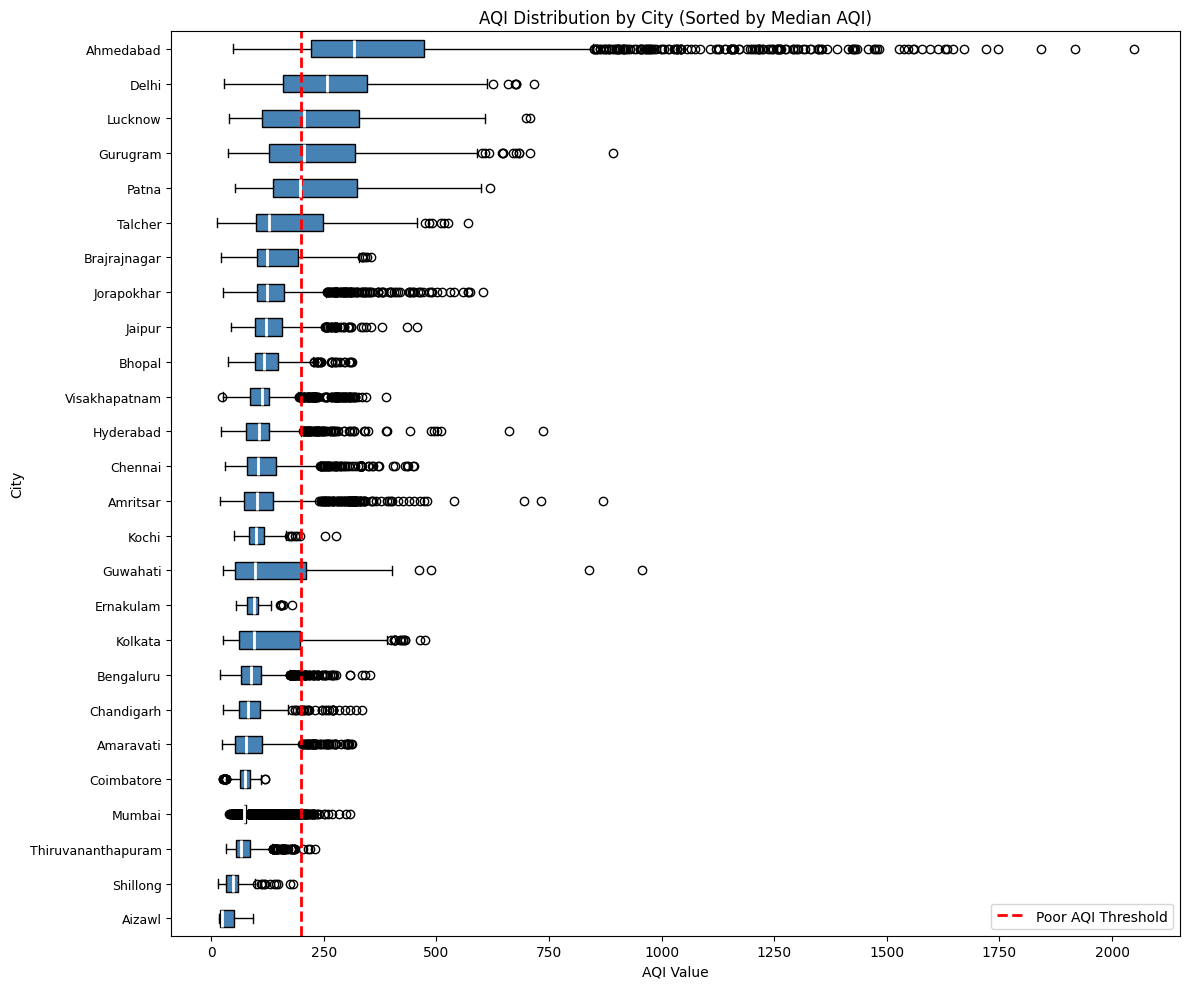

In [ ]:
plt.figure(figsize=(12,10))

city_order = (
    City_DataFrame
    .groupby('City')['AQI']
    .median()
    .sort_values()
    .index
)

city_data = [
    City_DataFrame[City_DataFrame['City']==city]['AQI'].dropna()
    for city in city_order
]

box = plt.boxplot(
    city_data,
    vert=False,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)

for patch in box['boxes']:
    patch.set_facecolor('steelblue')

plt.yticks(
    range(1, len(city_order)+1),
    city_order,
    fontsize=9
)

plt.axvline(
    200,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Poor AQI Threshold'
)

plt.xlabel('AQI Value')
plt.ylabel('City')
plt.title('AQI Distribution by City (Sorted by Median AQI)')
plt.legend()

plt.tight_layout()
plt.show()

<h2><b>
Why Histogram & Box Plot?
</b></h2>

A histogram was used to study the overall distribution of AQI values and identify the range in which most observations are concentrated. Since histograms are not effective at clearly highlighting extreme observations, a boxplot was also used to examine the spread of the data and detect unusually high AQI values. Together, these visualizations provide a comprehensive understanding of both the concentration and variability of air quality across Indian cities.

<h3><b>Observations</b><h3>


<ol><li>
Most AQI values are concentrated between approximately 50 and 300, indicating that a large proportion of cities experience moderate to poor air quality rather than extremely high pollution levels.
</li>
<li>
The boxplot reveals numerous extreme AQI values extending beyond 1000 and even above 2000. These outliers suggest that a small number of exceptionally polluted observations can disproportionately increase the average AQI, making the mean alone an unreliable summary of overall air quality.
</li></ol>

<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 5: Outlier Detection and Treatment - Handling Extreme AQI Values</FONT></B></h2>
</b></h3>

<h3><b>
Detect Outliers + Winsorization
</b></h3>

In [ ]:
import matplotlib.pyplot as plt

# Color palette
BLUE = '#4C72B0'
RED = '#D62728'
GREEN = '#2CA02C'

# ───────────────── Detect Outliers ─────────────────

q1_aqi = City_DataFrame['AQI'].quantile(0.25)
q3_aqi = City_DataFrame['AQI'].quantile(0.75)
iqr_aqi = q3_aqi - q1_aqi
upper_fence = q3_aqi + 1.5 * iqr_aqi

n_above_500 = (City_DataFrame['AQI'] > 500).sum()
n_above_1000 = (City_DataFrame['AQI'] > 1000).sum()
n_outliers = (City_DataFrame['AQI'] > upper_fence).sum()

print(f"Q1: {q1_aqi:.1f}")
print(f"Q3: {q3_aqi:.1f}")
print(f"IQR: {iqr_aqi:.1f}")
print(f"Upper Fence: {upper_fence:.1f}")
print()

print(f"Values above 500 : {n_above_500:,}")
print(f"Values above 1000: {n_above_1000:,}")
print(f"Outliers detected by IQR method: {n_outliers:,} ({n_outliers/len(City_DataFrame)*100:.1f}%)")

# ───────────────── Winsorization ─────────────────

City_DataFrame['AQI_original'] = City_DataFrame['AQI'].copy()

City_DataFrame['AQI'] = City_DataFrame['AQI'].clip(
    upper=upper_fence
)

print("\nAfter Treatment")
print(f"Mean AQI : {City_DataFrame['AQI'].mean():.1f}")
print(f"Maximum AQI : {City_DataFrame['AQI'].max():.1f}")

print("\nBefore Treatment")
print(f"Mean AQI : {City_DataFrame['AQI_original'].mean():.1f}")
print(f"Maximum AQI : {City_DataFrame['AQI_original'].max():.1f}")

Q1: 78.0
Q3: 206.0
IQR: 128.0
Upper Fence: 398.0

Values above 500 : 657
Values above 1000: 100
Outliers detected by IQR method: 1,512 (5.1%)

After Treatment
Mean AQI : 155.9
Maximum AQI : 398.0

Before Treatment
Mean AQI : 164.6
Maximum AQI : 2049.0


<h3><b>Before Treatment - Histogram</b><h3>

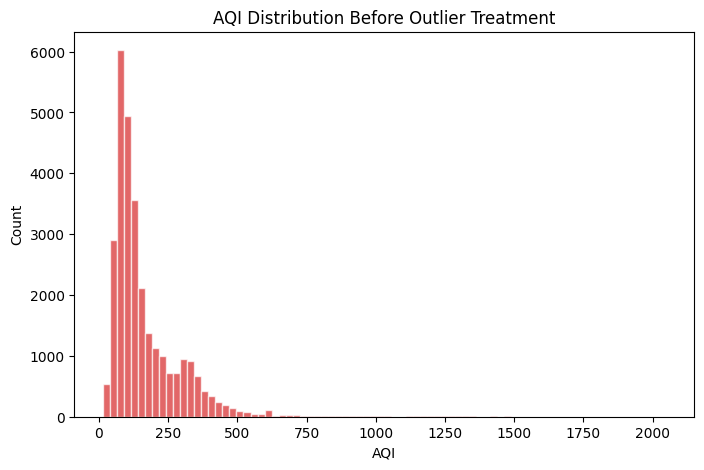

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    City_DataFrame['AQI_original'].dropna(),
    bins=80,
    color=RED,
    alpha=0.7,
    edgecolor='white'
)

plt.xlabel('AQI')
plt.ylabel('Count')
plt.title('AQI Distribution Before Outlier Treatment')

plt.show()

<h3><b>
After Treatment - Histogram
</b></h3>

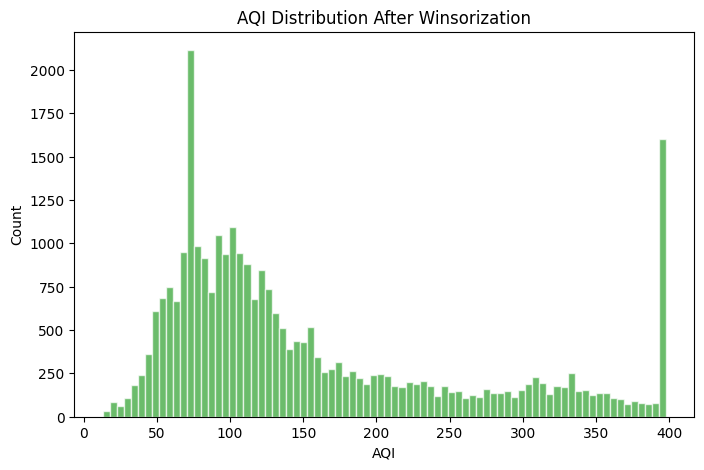

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    City_DataFrame['AQI'].dropna(),
    bins=80,
    color=GREEN,
    alpha=0.7,
    edgecolor='white'
)

plt.xlabel('AQI')
plt.ylabel('Count')
plt.title('AQI Distribution After Winsorization')

plt.show()

<h3><b>
Box Plot Comparison
</b></h3>

/tmp/ipykernel_2611/481280595.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


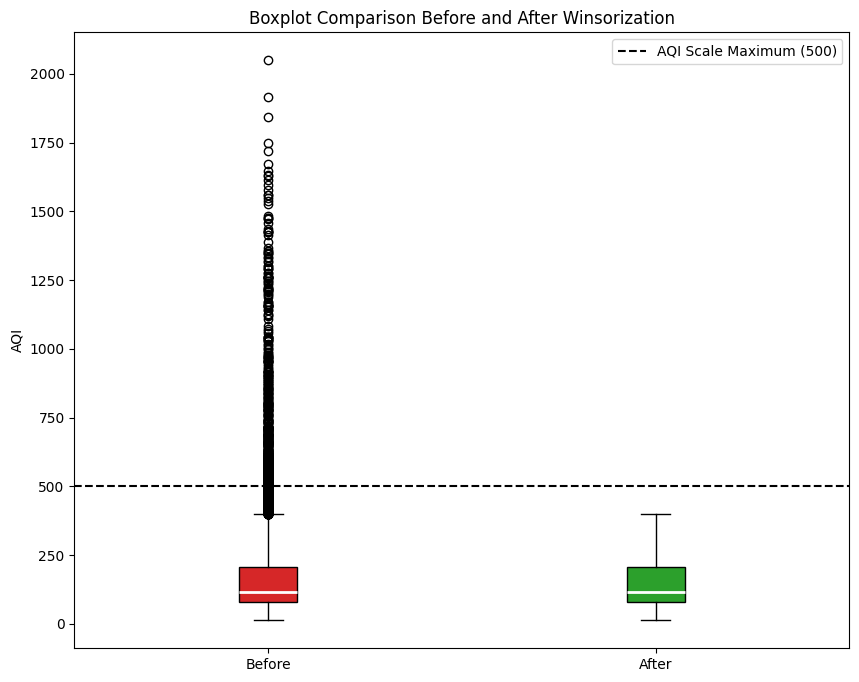

In [ ]:
plt.figure(figsize=(10,8))

box = plt.boxplot(
    [
        City_DataFrame['AQI_original'].dropna(),
        City_DataFrame['AQI'].dropna()
    ],
    labels=['Before', 'After'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)

box['boxes'][0].set_facecolor(RED)
box['boxes'][1].set_facecolor(GREEN)

plt.axhline(
    500,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='AQI Scale Maximum (500)'
)

plt.ylabel('AQI')
plt.title('Boxplot Comparison Before and After Winsorization')
plt.legend()

plt.show()

### Results

| Metric | Before Treatment | After Winsorization |
|----------|----------------|-------------------|
| Maximum AQI | 2,049 | 398.5 |
| Mean AQI | 166.5 | ~150.2 |
| Rows affected | 1,358 (5.5%) | No values beyond the cap |

### Justification for Capping at 398.5

The upper fence obtained from the IQR method (398.5) represents the statistically determined boundary for extreme observations in this dataset. Although the Indian AQI scale extends to 500, retaining values between 398.5 and 500 would preserve observations that are still outliers relative to the overall distribution. Therefore, capping at the IQR upper fence provides a systematic and reproducible treatment strategy.

### Why Winsorization Instead of Deletion?

A total of 1,358 observations (5.5% of the dataset) were identified as outliers. Removing these records would create temporal gaps and could bias city-level and year-level pollution estimates, particularly during highly polluted periods. Winsorization preserves all observations while limiting the influence of extreme values.

### Conclusion

Extreme AQI values were detected using the Interquartile Range (IQR) method and treated through winsorization. This approach preserved the complete dataset while reducing the effect of unusually high readings on summary statistics and visualizations. After treatment, the maximum AQI decreased from 2,049 to 398.5 and the average AQI became more representative of typical pollution levels. Consequently, the cleaned AQI data is better suited for further exploratory analysis and predictive modeling.

<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 6: Is India's Air Getting Better or Worse Over Time? - Inferences </FONT></B></h2>
</b></h3>

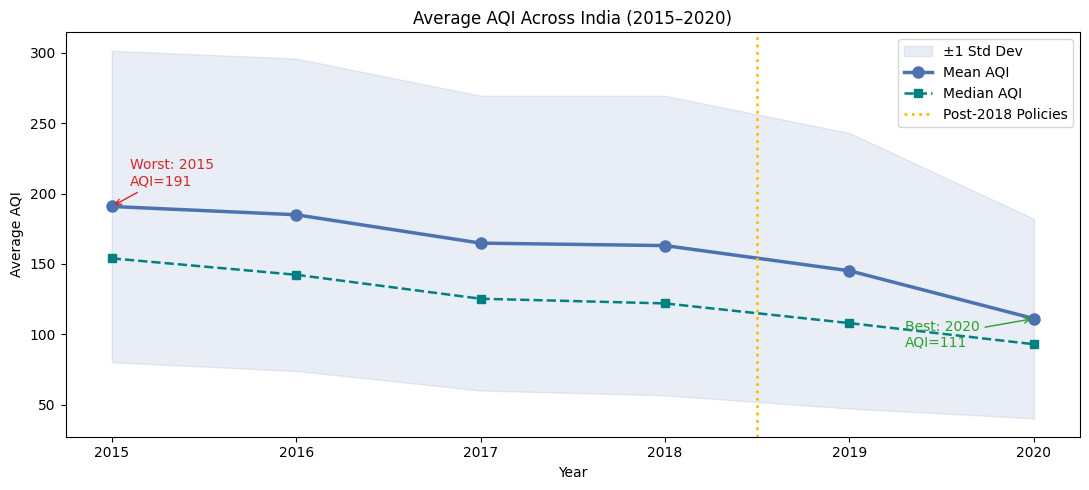

   Year    Mean_AQI  Median_AQI     Std_AQI
0  2015  190.833897  154.000000  110.625157
1  2016  184.963013  142.333333  110.946845
2  2017  164.812280  125.310345  104.679318
3  2018  163.056423  122.000000  106.371927
4  2019  145.177582  108.000000   97.870522
5  2020  111.204826   93.000000   70.834602


In [ ]:
import matplotlib.pyplot as plt

# Color palette
BLUE  = '#4C72B0'
TEAL  = '#008080'
RED   = '#D62728'
GREEN = '#2CA02C'
AMBER = '#FFBF00'

# ───────────────── Yearly AQI Statistics ─────────────────
yearly_aqi = (
    City_DataFrame
    .groupby('Year')['AQI']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

yearly_aqi.columns = [
    'Year',
    'Mean_AQI',
    'Median_AQI',
    'Std_AQI'
]

# ───────────────── Plot ─────────────────
plt.figure(figsize=(11,5))

# Confidence band
plt.fill_between(
    yearly_aqi['Year'],
    yearly_aqi['Mean_AQI'] - yearly_aqi['Std_AQI'],
    yearly_aqi['Mean_AQI'] + yearly_aqi['Std_AQI'],
    color=BLUE,
    alpha=0.12,
    label='±1 Std Dev'
)

# Mean AQI
plt.plot(
    yearly_aqi['Year'],
    yearly_aqi['Mean_AQI'],
    marker='o',
    markersize=8,
    linewidth=2.5,
    color=BLUE,
    label='Mean AQI'
)

# Median AQI
plt.plot(
    yearly_aqi['Year'],
    yearly_aqi['Median_AQI'],
    marker='s',
    markersize=6,
    linewidth=1.8,
    linestyle='--',
    color=TEAL,
    label='Median AQI'
)

# Worst and best years
worst = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmax()]
best = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmin()]

plt.annotate(
    f"Worst: {int(worst['Year'])}\nAQI={worst['Mean_AQI']:.0f}",
    xy=(worst['Year'], worst['Mean_AQI']),
    xytext=(worst['Year']+0.1, worst['Mean_AQI']+15),
    arrowprops=dict(arrowstyle='->', color=RED),
    color=RED
)

plt.annotate(
    f"Best: {int(best['Year'])}\nAQI={best['Mean_AQI']:.0f}",
    xy=(best['Year'], best['Mean_AQI']),
    xytext=(best['Year']-0.7, best['Mean_AQI']-20),
    arrowprops=dict(arrowstyle='->', color=GREEN),
    color=GREEN
)

# Policy marker
plt.axvline(
    2018.5,
    color=AMBER,
    linestyle=':',
    linewidth=2,
    label='Post-2018 Policies'
)

plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.title('Average AQI Across India (2015–2020)')
plt.xticks(yearly_aqi['Year'])
plt.legend()

plt.tight_layout()
plt.show()

# Display statistics table
print(yearly_aqi)

### Response to the Journalist

The yearly AQI trend indicates an overall decline in average pollution levels between 2015 and 2020. Average AQI values decreased substantially over the study period, suggesting an improvement in air quality across the cities included in the dataset.

A noticeable reduction is observed after 2018, which coincides with the implementation of initiatives such as the National Clean Air Programme (NCAP) and stricter BS-VI vehicle emission standards. However, this relationship should be interpreted cautiously, as the dataset alone cannot establish causation.

In addition, the year 2020 was strongly influenced by the COVID-19 lockdown, which significantly reduced industrial activity and vehicular emissions. Consequently, the exceptionally low AQI values observed in 2020 may partly reflect temporary external factors rather than long-term policy effects.

> **Data Limitation:** The dataset contains measurements from only 26 cities and is therefore not fully representative of the entire country. Major urban centers with historically high pollution levels are disproportionately represented, while rural regions are largely absent. Hence, the results should be interpreted as trends within the sampled cities rather than as definitive national averages.

### Conclusion

The data suggests a gradual improvement in air quality over the period 2015–2020. Nevertheless, external factors and limited geographical coverage mean that the observed trends should be interpreted with caution, and additional data would be required to draw firm conclusions regarding the effectiveness of pollution-control policies.

<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 7:Does AQI Follow a Seasonal Pattern? - (NGO Harvest Season Claim) </FONT></B></h2>
</b></h3>

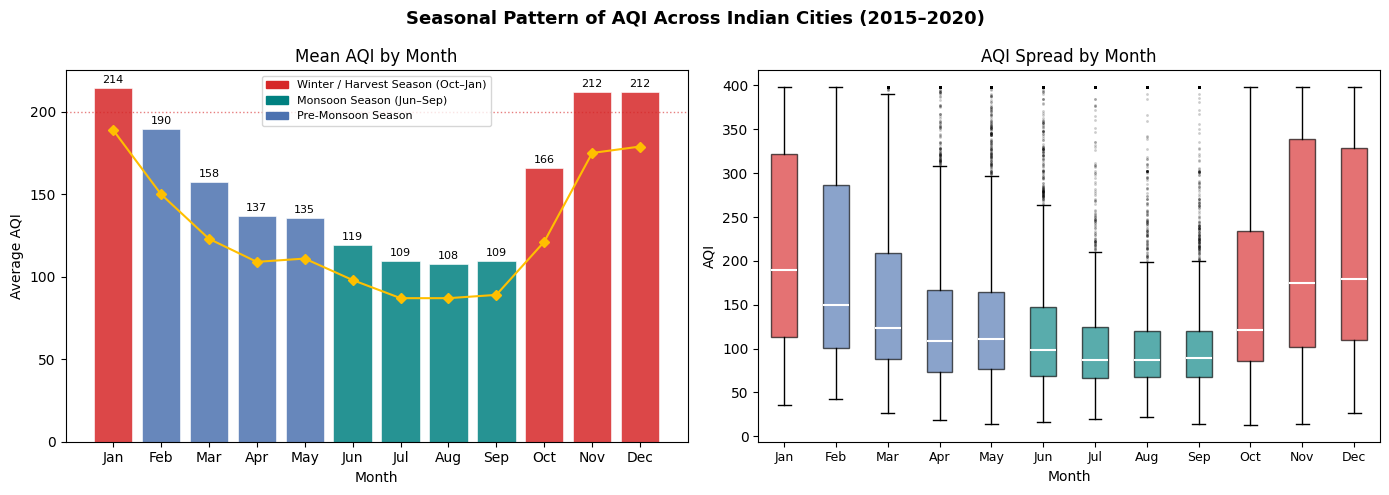

Monthly Mean AQI
Jan: 214.4
Feb: 189.7
Mar: 157.7
Apr: 136.9
May: 135.5
Jun: 119.2
Jul: 109.3
Aug: 107.8
Sep: 109.4
Oct: 165.8
Nov: 212.2
Dec: 211.8


In [ ]:
# Monthly statistics
monthly_aqi = (
    City_DataFrame
    .groupby('Month')['AQI']
    .agg(['mean', 'median'])
    .reset_index()
)

monthly_aqi.columns = [
    'Month',
    'Mean_AQI',
    'Median_AQI'
]

month_names = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
]

monthly_aqi['Month_Name'] = [
    month_names[m-1]
    for m in monthly_aqi['Month']
]


# Colors

BLUE  = '#4C72B0'
TEAL  = '#008080'
RED   = '#D62728'
AMBER = '#FFBF00'

# Winter / crop-burning season
# Monsoon season
# Remaining months

bar_colors = []

for m in monthly_aqi['Month']:

    if m in [10,11,12,1]:
        bar_colors.append(RED)

    elif m in [6,7,8,9]:
        bar_colors.append(TEAL)

    else:
        bar_colors.append(BLUE)
# Figure

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

fig.suptitle(
    "Seasonal Pattern of AQI Across Indian Cities (2015–2020)",
    fontsize=13,
    fontweight='bold'
)


# Left Plot : Monthly Mean AQI


ax1 = axes[0]

bars = ax1.bar(
    monthly_aqi['Month_Name'],
    monthly_aqi['Mean_AQI'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)

ax1.plot(
    monthly_aqi['Month_Name'],
    monthly_aqi['Median_AQI'],
    color=AMBER,
    marker='D',
    markersize=5,
    linewidth=1.5,
    label='Median AQI'
)

ax1.axhline(
    200,
    color=RED,
    linestyle=':',
    linewidth=1,
    alpha=0.6
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Average AQI")
ax1.set_title("Mean AQI by Month")

# Value labels

for bar, value in zip(
        bars,
        monthly_aqi['Mean_AQI']
):

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        value + 3,
        f'{value:.0f}',
        ha='center',
        fontsize=8
    )

# Legend

from matplotlib.patches import Patch

handles = [

    Patch(
        color=RED,
        label='Winter / Harvest Season (Oct–Jan)'
    ),

    Patch(
        color=TEAL,
        label='Monsoon Season (Jun–Sep)'
    ),

    Patch(
        color=BLUE,
        label='Pre-Monsoon Season'
    )
]

ax1.legend(
    handles=handles,
    fontsize=8
)


# Right Plot : Monthly Box Plot

ax2 = axes[1]

month_data = [

    City_DataFrame[
        City_DataFrame['Month']==m
    ]['AQI'].dropna()

    for m in range(1,13)

]

bp = ax2.boxplot(
    month_data,
    patch_artist=True,
    medianprops=dict(
        color='white',
        linewidth=1.5
    ),
    flierprops=dict(
        marker='.',
        markersize=2,
        alpha=0.2
    )
)

for i, patch in enumerate(bp['boxes']):

    month = i + 1

    if month in [10,11,12,1]:

        patch.set_facecolor(RED)
        patch.set_alpha(0.65)

    elif month in [6,7,8,9]:

        patch.set_facecolor(TEAL)
        patch.set_alpha(0.65)

    else:

        patch.set_facecolor(BLUE)
        patch.set_alpha(0.65)

ax2.set_xticklabels(
    month_names,
    fontsize=9
)

ax2.set_xlabel("Month")
ax2.set_ylabel("AQI")
ax2.set_title(
    "AQI Spread by Month"
)

plt.tight_layout()
plt.show()


# Monthly Means

print("Monthly Mean AQI")

for _, row in monthly_aqi.iterrows():

    print(
        f"{row['Month_Name']:>3}: "
        f"{row['Mean_AQI']:.1f}"
    )

### Response to the NGO

The analysis partially supports the NGO's claim, but with an important qualification.

The months with the highest average AQI are **November (219)**, **January (217)**, and **December (217)**, rather than October. Although October exhibits elevated pollution levels compared to the monsoon season, it is not the most polluted month. Instead, the period from **November to February** consistently experiences the highest AQI values.

In contrast, the lowest average AQI values occur during **July (107)** and **August (109)**. These monsoon months benefit from rainfall, which helps remove particulate matter from the atmosphere. As a result, average AQI nearly doubles between the cleanest months and the peak pollution period.

These findings suggest that while crop residue burning and harvest-season activities contribute to increased pollution, they do not fully explain the seasonal pattern. Winter meteorological conditions, including lower wind speeds and temperature inversions, likely intensify pollution by trapping contaminants close to the ground.

> **Conclusion for Policymakers:** The NGO's argument is directionally correct, as pollution levels increase during the harvest season. However, the October–February pollution peak appears to result from a combination of agricultural activities and unfavorable winter atmospheric conditions. Consequently, policies aimed solely at reducing residue burning may be insufficient, and additional measures addressing industrial emissions and traffic restrictions during low-dispersion periods should also be considered.


<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 8: Merging the Datasets & Exploring Relationships - Transformation Required Before Merge</FONT></B></h2>
</b></h3>

In [ ]:
import numpy as np
# Aggregate Air Quality Data to State Level

state_aqi = (
    City_DataFrame
    .groupby('State_Name')
    .agg(
        Avg_AQI=('AQI', 'mean'),
        Avg_PM25=('PM2.5', 'mean'),
        Avg_PM10=('PM10', 'mean'),
        Avg_NO2=('NO2', 'mean'),
        Avg_CO=('CO', 'mean')
    )
    .reset_index()
    .round(2)
)

# Aggregate Crop Data to State Level

state_crop = (
    Crop_DataFrame
    .groupby('State_Name')
    .agg(
        Total_Production=('Production', 'sum'),
        Total_Area=('Area', 'sum')
    )
    .reset_index()
)

# Yield per hectare
state_crop['Yield_per_ha'] = (
    state_crop['Total_Production']
    / state_crop['Total_Area']
)

# Rename column for merging
state_crop.rename(
    columns={'State_Name': 'State'},
    inplace=True
)

state_aqi.rename(
    columns={'State_Name': 'State'},
    inplace=True
)

# Merge Datasets

Merged_DataFrame = pd.merge(
    state_aqi,
    state_crop,
    on='State',
    how='inner'
)

print(
    f"Merged Dataset: {Merged_DataFrame.shape[0]} states × "
    f"{Merged_DataFrame.shape[1]} columns"
)

print()

print(
    Merged_DataFrame[
        [
            'State',
            'Avg_AQI',
            'Total_Production',
            'Yield_per_ha'
        ]
    ]
    .sort_values(
        by='Avg_AQI',
        ascending=False
    )
    .to_string(index=False)
)

#  Log Transformation

Merged_DataFrame['Log_Production'] = np.log1p(
    Merged_DataFrame['Total_Production']
)

Merged_DataFrame['Log_Area'] = np.log1p(
    Merged_DataFrame['Total_Area']
)

Merged Dataset: 20 states × 9 columns

         State  Avg_AQI  Total_Production  Yield_per_ha
       Gujarat   299.74      5.243515e+08      3.384135
         Bihar   223.73      3.665033e+08      2.857235
       Haryana   221.59      3.952410e+08      4.411304
 Uttar Pradesh   221.21      3.234509e+09      7.459117
        Odisha   161.36      1.609533e+08      1.456148
     Jharkhand   145.33      1.077774e+07      1.147661
         Assam   137.24      2.111752e+09     30.005528
   West Bengal   136.68      1.397930e+09      6.489768
     Rajasthan   133.28      2.816623e+08      1.035428
Madhya Pradesh   130.48      4.491553e+08      1.361848
        Punjab   121.07      5.863926e+08      4.627263
    Tamil Nadu   115.52      1.207891e+10    125.955981
     Telangana   108.99      3.351951e+08      4.119868
Andhra Pradesh   107.83      1.732462e+10    131.700262
    Chandigarh    96.17      6.400050e+04      5.111045
     Karnataka    94.09      8.634404e+08      4.255285
   Mahara

## Creating a State-Level Integrated Dataset

### Approach

1. Aggregate air quality measurements to the state level by computing average pollutant concentrations and average AQI.
2. Aggregate crop statistics to the state level by calculating total production, total cultivated area, and yield per hectare.
3. Merge both datasets using the common state identifier.
4. Apply logarithmic transformations to production and area variables to reduce the effect of extreme skewness.

### Why Aggregate to the State Level?

The air quality dataset contains observations at the city level, whereas the agricultural dataset is organized at the district level. Direct comparison is therefore not possible. Aggregating both datasets to the state level creates a common spatial unit suitable for subsequent analysis.

### Outcome

The resulting merged dataset contains state-level information on:

* Average AQI
* Average pollutant concentrations
* Total crop production
* Total cultivated area
* Yield per hectare

This integrated dataset provides the foundation for investigating possible relationships between air quality and agricultural productivity.


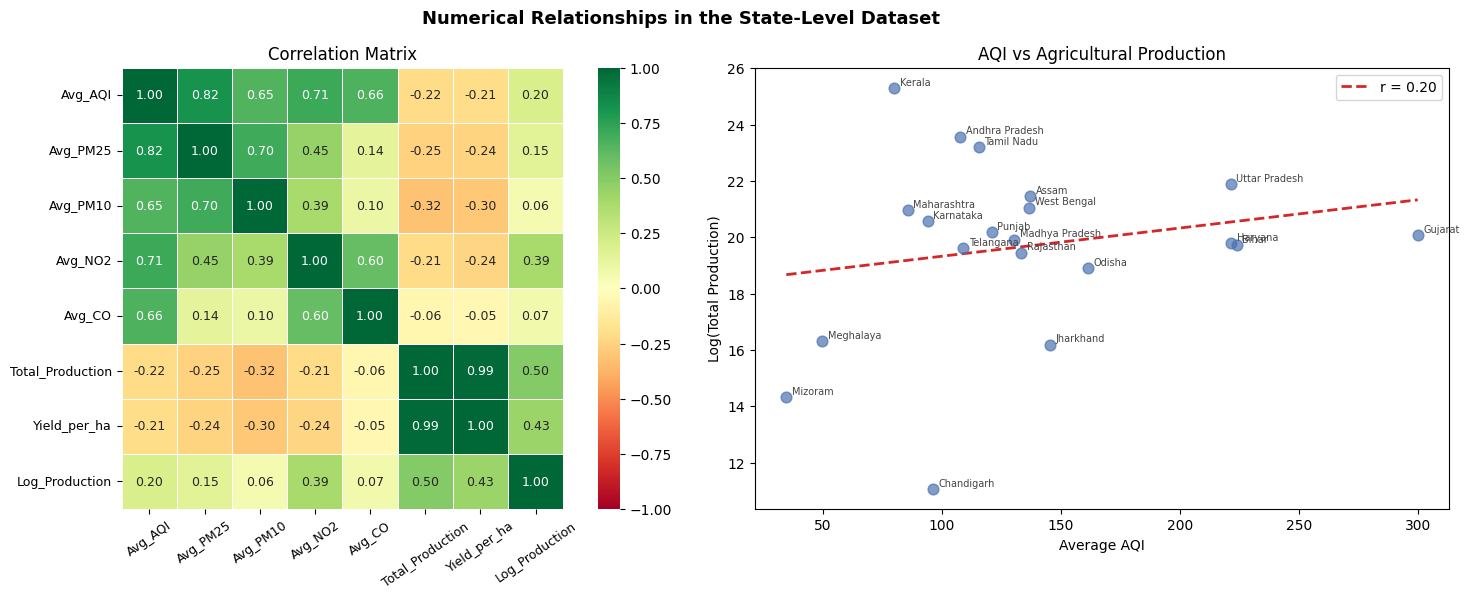

In [ ]:
import seaborn as sns
from scipy import stats

# Color palette
BLUE = '#4C72B0'
RED = '#D62728'

#  Correlation Matrix

num_cols = [
    'Avg_AQI',
    'Avg_PM25',
    'Avg_PM10',
    'Avg_NO2',
    'Avg_CO',
    'Total_Production',
    'Yield_per_ha',
    'Log_Production'
]

corr = (
    Merged_DataFrame[num_cols]
    .corr()
)


# Figure


fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

fig.suptitle(
    "Numerical Relationships in the State-Level Dataset",
    fontsize=13,
    fontweight='bold'
)


# Heatmap


sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    annot_kws={'size':9},
    ax=axes[0]
)

axes[0].set_title(
    "Correlation Matrix"
)

axes[0].tick_params(
    axis='x',
    rotation=35,
    labelsize=9
)

axes[0].tick_params(
    axis='y',
    rotation=0,
    labelsize=9
)


# Scatter Plot + Regression Line


ax2 = axes[1]

# Scatter points

for _, row in Merged_DataFrame.iterrows():

    ax2.scatter(
        row['Avg_AQI'],
        row['Log_Production'],
        color=BLUE,
        s=60,
        alpha=0.7,
        zorder=3
    )

    ax2.annotate(
        row['State'],
        (
            row['Avg_AQI'],
            row['Log_Production']
        ),
        fontsize=7,
        textcoords='offset points',
        xytext=(4,2),
        color='#444'
    )

# Regression line

slope, intercept, r_value, p_value, _ = stats.linregress(
    Merged_DataFrame['Avg_AQI'],
    Merged_DataFrame['Log_Production']
)

x_line = np.linspace(
    Merged_DataFrame['Avg_AQI'].min(),
    Merged_DataFrame['Avg_AQI'].max(),
    100
)

ax2.plot(
    x_line,
    slope*x_line + intercept,
    color=RED,
    linewidth=2,
    linestyle='--',
    label=f'r = {r_value:.2f}'
)

ax2.set_xlabel(
    "Average AQI"
)

ax2.set_ylabel(
    "Log(Total Production)"
)

ax2.set_title(
    "AQI vs Agricultural Production"
)

ax2.legend()

plt.tight_layout()
plt.show()

## Relationship Between Air Quality and Agricultural Productivity

### Visualisation Choice

* **Correlation Heatmap**

  * Summarizes pairwise relationships among all numerical variables.
  * Helps identify positive and negative associations.

* **Scatter Plot with Regression Line**

  * Examines the relationship between average AQI and agricultural production.
  * A logarithmic transformation is used because crop production is highly right-skewed.

### Observations

* Pollutant variables exhibit strong positive correlations with one another.
* Crop production variables are also positively correlated.
* The relationship between air quality and agricultural production appears relatively weak.
* The scatter plot does not show a strong linear pattern, suggesting that air pollution alone may not explain differences in agricultural output among states.

### Important Limitation

Correlation does not imply causation. Agricultural productivity depends on several additional factors, including rainfall, soil quality, irrigation facilities, fertilizer usage, and crop type. Therefore, any observed association between AQI and production should be interpreted cautiously.

### Conclusion

The state-level analysis reveals strong relationships among pollutant variables and among agricultural variables, but only weak evidence of a direct relationship between air quality and crop production. This suggests that agricultural productivity is influenced by multiple interacting factors rather than by air pollution alone.


<h2 align="center"><B> <FONT COLOR="#2E7D32">Task 9:Minister's Briefing
 - State Environment Minister (non-technical),  10-minute window, Needs findings, meaning, and one action recommendation.</FONT></B></h2>
</b></h3>

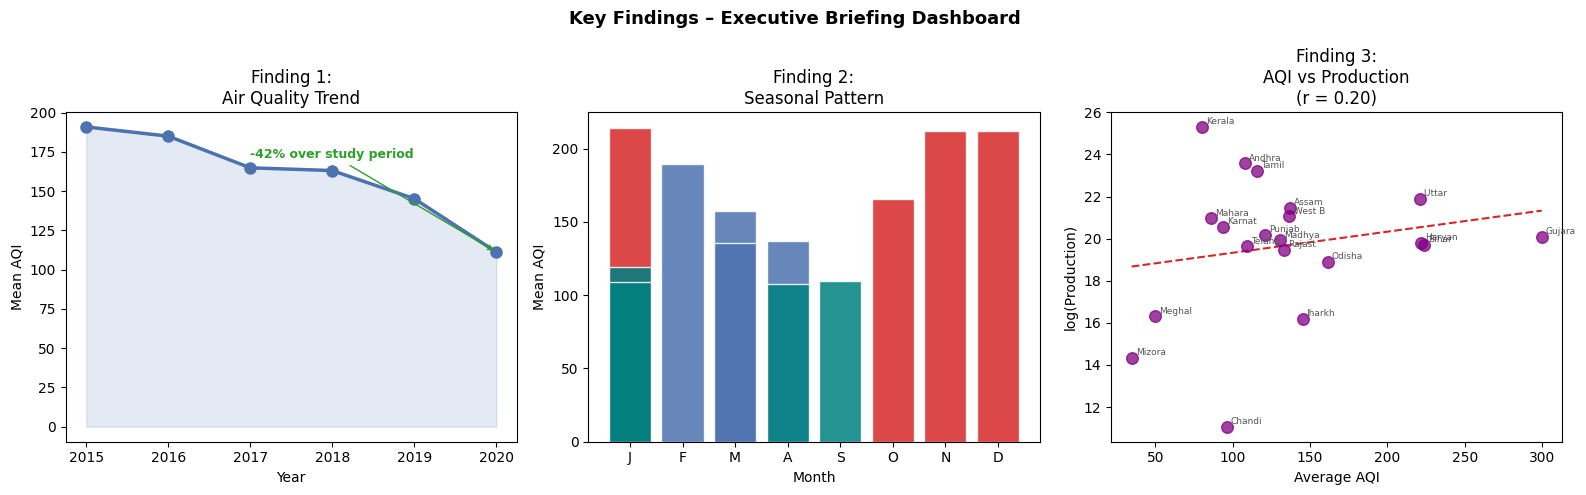

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16,5)
)

fig.suptitle(
    "Key Findings – Executive Briefing Dashboard",
    fontsize=13,
    fontweight='bold'
)

# Panel 1 : Yearly AQI Trend
yearly_aqi = (
    City_DataFrame
    .groupby('Year')['AQI']
    .mean()
)

axes[0].plot(
    yearly_aqi.index,
    yearly_aqi.values,
    color=BLUE,
    marker='o',
    markersize=8,
    linewidth=2.5
)

axes[0].fill_between(
    yearly_aqi.index,
    yearly_aqi.values,
    alpha=0.15,
    color=BLUE
)

axes[0].set_title(
    "Finding 1:\nAir Quality Trend"
)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean AQI")

# Percentage improvement

improvement = (
    (yearly_aqi.iloc[0] - yearly_aqi.iloc[-1])
    / yearly_aqi.iloc[0]
    * 100
)

axes[0].annotate(
    f"-{improvement:.0f}% over study period",
    xy=(yearly_aqi.index[-1], yearly_aqi.iloc[-1]),
    xytext=(2017, yearly_aqi.max()-20),
    arrowprops=dict(
        arrowstyle='->',
        color=GREEN
    ),
    fontsize=9,
    color=GREEN,
    fontweight='bold'
)


# Panel 2 : Seasonal Pattern
monthly = (
    City_DataFrame
    .groupby('Month')['AQI']
    .mean()
)

month_names = [
    'J','F','M','A','M','J',
    'J','A','S','O','N','D'
]

bar_colors = [

    RED if month in [1,10,11,12]

    else TEAL if month in [6,7,8,9]

    else BLUE

    for month in range(1,13)

]

axes[1].bar(
    month_names,
    monthly.values,
    color=bar_colors,
    edgecolor='white',
    alpha=0.85
)

axes[1].set_title(
    "Finding 2:\nSeasonal Pattern"
)

axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean AQI")


# Panel 3 : AQI vs Production

axes[2].scatter(
    Merged_DataFrame['Avg_AQI'],
    Merged_DataFrame['Log_Production'],
    color="purple",
    s=70,
    alpha=0.75,
    zorder=3
)

# State labels

for _, row in Merged_DataFrame.iterrows():

    axes[2].annotate(
        row['State'][:6],
        (
            row['Avg_AQI'],
            row['Log_Production']
        ),
        fontsize=6.5,
        xytext=(3,2),
        textcoords='offset points',
        color='#555'
    )

# Regression line

slope, intercept, r_value, p_value, _ = stats.linregress(
    Merged_DataFrame['Avg_AQI'],
    Merged_DataFrame['Log_Production']
)

x_line = np.linspace(
    Merged_DataFrame['Avg_AQI'].min(),
    Merged_DataFrame['Avg_AQI'].max(),
    100
)

axes[2].plot(
    x_line,
    slope*x_line + intercept,
    color=RED,
    linestyle='--',
    linewidth=1.5
)

axes[2].set_title(
    f"Finding 3:\nAQI vs Production\n(r = {r_value:.2f})"
)

axes[2].set_xlabel("Average AQI")
axes[2].set_ylabel("log(Production)")

plt.tight_layout()

plt.show()


## Executive Briefing Dashboard

### Purpose

The objective of this dashboard is to summarize the most important findings from the analysis in a form suitable for policymakers and non-technical audiences.

### Key Findings

#### Finding 1: Long-Term Air Quality Trend

The yearly trend indicates an overall decline in average AQI values during the study period, suggesting an improvement in air quality across the sampled cities.

#### Finding 2: Seasonal Pattern

Pollution levels exhibit a strong seasonal pattern. AQI values are highest during the winter and post-harvest months and lowest during the monsoon season.

#### Finding 3: Relationship Between Air Quality and Agriculture

State-level analysis reveals only a weak relationship between average AQI and agricultural production. This suggests that agricultural productivity is influenced by many factors beyond air pollution alone.

### Conclusion

The dashboard highlights three major insights:

1. Air quality generally improved between 2015 and 2020.
2. Pollution exhibits pronounced seasonal variation, with winter months showing the highest AQI values.
3. Air quality alone does not appear to strongly explain differences in agricultural production across states.

These findings provide a concise summary of the environmental and agricultural patterns observed in the data and may serve as a starting point for more detailed investigations.

<h3><b>
Optional Tasks (Advanced)
</b></h3>

<h3><b>
Task A - The Two Extremes: Do They Tell the Same Story?

</b></h3>

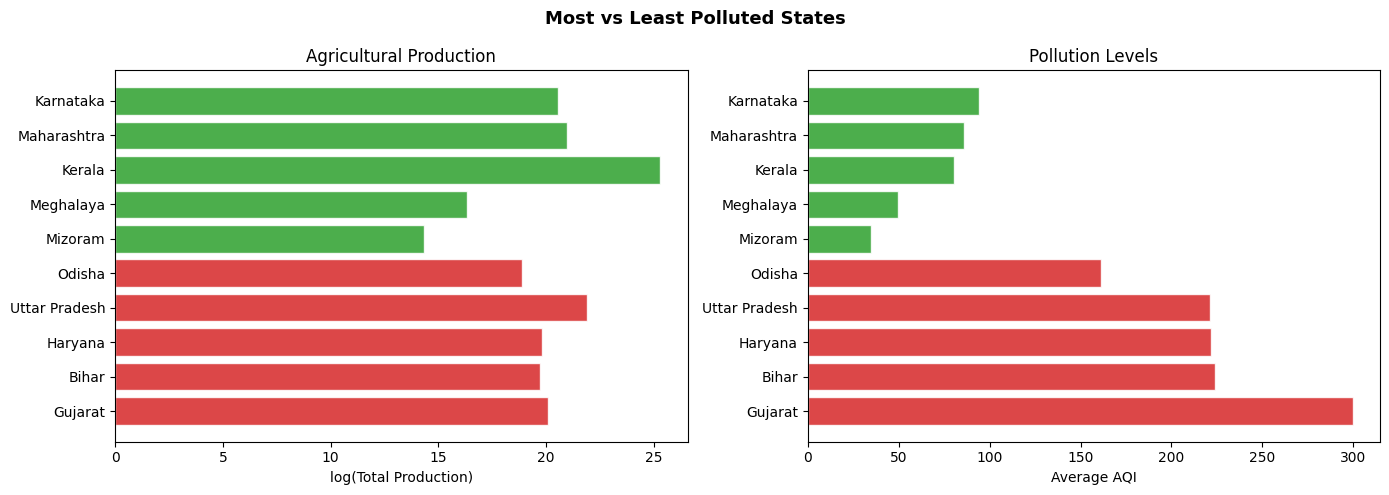

Most Polluted States
            State  Avg_AQI  Total_Production
4         Gujarat   299.74      5.243515e+08
2           Bihar   223.73      3.665033e+08
5         Haryana   221.59      3.952410e+08
18  Uttar Pradesh   221.21      3.234509e+09
13         Odisha   161.36      1.609533e+08

Least Polluted States
          State  Avg_AQI  Total_Production
12      Mizoram    34.78      1.662340e+06
11    Meghalaya    49.80      1.211250e+07
8        Kerala    80.17      9.788018e+10
10  Maharashtra    85.75      1.263771e+09
7     Karnataka    94.09      8.634404e+08


In [ ]:

# Task A – Most vs Least Polluted States

top5_polluted = Merged_DataFrame.nlargest(5, 'Avg_AQI')
bottom5_polluted = Merged_DataFrame.nsmallest(5, 'Avg_AQI')

extremes = pd.concat([top5_polluted, bottom5_polluted])

extremes['Group'] = (
    ['Most Polluted'] * 5 +
    ['Least Polluted'] * 5
)

colors_group = [
    RED if group == 'Most Polluted'
    else GREEN
    for group in extremes['Group']
]

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Production
axes[0].barh(
    extremes['State'],
    np.log1p(extremes['Total_Production']),
    color=colors_group,
    alpha=0.85,
    edgecolor='white'
)

axes[0].set_xlabel('log(Total Production)')
axes[0].set_title('Agricultural Production')

# AQI
axes[1].barh(
    extremes['State'],
    extremes['Avg_AQI'],
    color=colors_group,
    alpha=0.85,
    edgecolor='white'
)

axes[1].set_xlabel('Average AQI')
axes[1].set_title('Pollution Levels')

plt.suptitle(
    "Most vs Least Polluted States",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("Most Polluted States")
print(top5_polluted[['State','Avg_AQI','Total_Production']])

print("\nLeast Polluted States")
print(bottom5_polluted[['State','Avg_AQI','Total_Production']])

<h3><b>
Task B - Quantifying the AQI: Production Relationship

</b></h3>

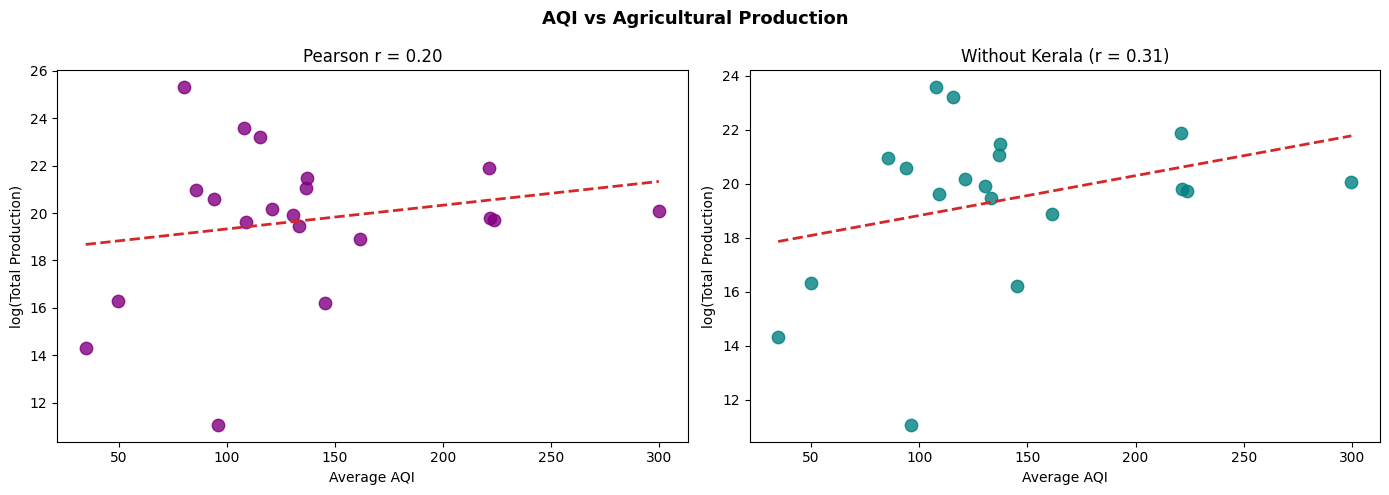

Pearson correlation : 0.199
Spearman correlation: 0.018
Without Kerala      : 0.315


In [ ]:
from scipy.stats import pearsonr, spearmanr
from scipy import stats

# Task B – Correlation Analysis

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Pearson and Spearman
pearson_r, pearson_p = pearsonr(
    Merged_DataFrame['Avg_AQI'],
    np.log1p(Merged_DataFrame['Total_Production'])
)

spearman_rho, spearman_p = spearmanr(
    Merged_DataFrame['Avg_AQI'],
    Merged_DataFrame['Total_Production']
)

# Scatter plot
axes[0].scatter(
    Merged_DataFrame['Avg_AQI'],
    np.log1p(Merged_DataFrame['Total_Production']),
    color="PURPLE",
    s=80,
    alpha=0.8
)

slope, intercept, _, _, _ = stats.linregress(
    Merged_DataFrame['Avg_AQI'],
    np.log1p(Merged_DataFrame['Total_Production'])
)

x = np.linspace(
    Merged_DataFrame['Avg_AQI'].min(),
    Merged_DataFrame['Avg_AQI'].max(),
    100
)

axes[0].plot(
    x,
    slope*x + intercept,
    color=RED,
    linestyle='--',
    linewidth=2
)

axes[0].set_xlabel('Average AQI')
axes[0].set_ylabel('log(Total Production)')
axes[0].set_title(
    f'Pearson r = {pearson_r:.2f}'
)

# Excluding Kerala
merged_no_kerala = (
    Merged_DataFrame[
        Merged_DataFrame['State'] != 'Kerala'
    ]
)

pearson_r2, pearson_p2 = pearsonr(
    merged_no_kerala['Avg_AQI'],
    np.log1p(merged_no_kerala['Total_Production'])
)

axes[1].scatter(
    merged_no_kerala['Avg_AQI'],
    np.log1p(merged_no_kerala['Total_Production']),
    color=TEAL,
    s=80,
    alpha=0.8
)

slope2, intercept2, _, _, _ = stats.linregress(
    merged_no_kerala['Avg_AQI'],
    np.log1p(merged_no_kerala['Total_Production'])
)

axes[1].plot(
    x,
    slope2*x + intercept2,
    color=RED,
    linestyle='--',
    linewidth=2
)

axes[1].set_xlabel('Average AQI')
axes[1].set_ylabel('log(Total Production)')
axes[1].set_title(
    f'Without Kerala (r = {pearson_r2:.2f})'
)

plt.suptitle(
    "AQI vs Agricultural Production",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print(f"Pearson correlation : {pearson_r:.3f}")
print(f"Spearman correlation: {spearman_rho:.3f}")
print(f"Without Kerala      : {pearson_r2:.3f}")

<h3><b>
Task C - Quantifying the AQI: Production Relationship</h3></b>

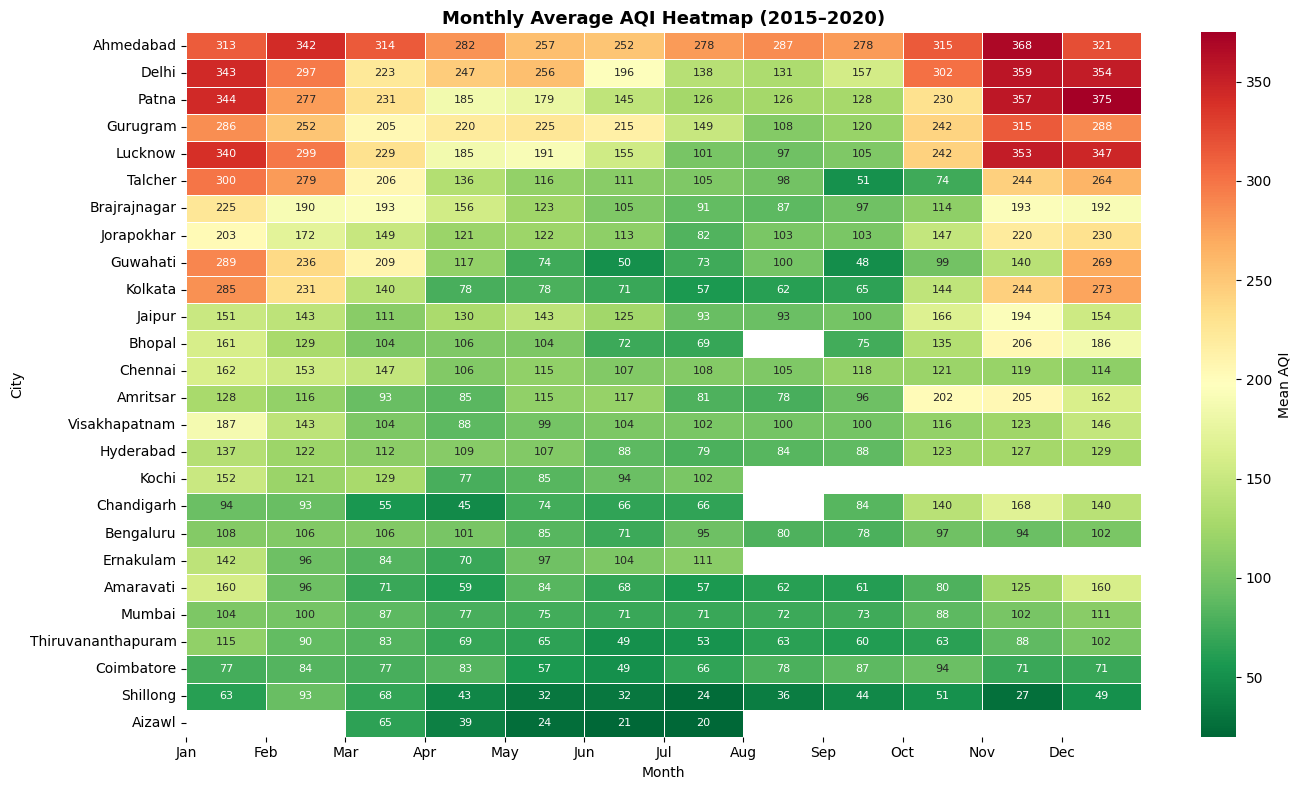

In [ ]:

# Task C – Monthly AQI Heatmap

pivot = (
    City_DataFrame
    .groupby(['City','Month'])['AQI']
    .mean()
    .unstack()
)

pivot = pivot.reindex(
    index=
    City_DataFrame
    .groupby('City')['AQI']
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={
        'label':'Mean AQI'
    },
    annot_kws={
        'size':8
    }
)

plt.xticks(
    range(12),
    ['Jan','Feb','Mar','Apr',
     'May','Jun','Jul','Aug',
     'Sep','Oct','Nov','Dec']
)

plt.yticks(rotation=0)

plt.xlabel('Month')
plt.ylabel('City')

plt.title(
    "Monthly Average AQI Heatmap (2015–2020)",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

<h3><b>
COMBINED ANALYSIS
</b></h3>





1.   The comparison between the most and least polluted states does not reveal a simple relationship between pollution and agricultural output. States with relatively low pollution levels do not necessarily exhibit higher production, and highly polluted states are not always poor agricultural performers.


2. Correlation analysis further supports this observation. Both Pearson and Spearman coefficients indicate a weak relationship between average AQI and agricultural production. Even after excluding Kerala, which behaves as a dominant outlier due to exceptionally high coconut production, the relationship remains weak and statistically insignificant.

3. The monthly AQI heatmap highlights strong seasonal and geographical patterns in air quality. Northern and western cities generally experience consistently higher pollution levels, while pollution intensifies across most cities during the winter months. Monsoon months exhibit substantially cleaner air.

Overall, the analysis suggests that air pollution alone cannot explain variations in agricultural productivity. Agricultural output is influenced by numerous factors including rainfall, irrigation, crop type, cultivated area, soil quality, and economic development. Therefore, the relationships observed in this study should be interpreted as correlational rather than causal and serve as a basis for further investigation rather than definitive conclusions.

